# Synthetic lemon generation with the released Conditional GAN — *Fruit Quality and Defect Image Classification with Conditional GAN Data Augmentation*

**Paper:** Jordan J. Bird, Chloe M. Barnes, Luis J. Manso, Anikó Ekárt, Diego R. Faria,
*Fruit Quality and Defect Image Classification with Conditional GAN Data Augmentation*,
[arXiv:2104.05647v1](https://arxiv.org/abs/2104.05647) (2021); journal version
*Scientia Horticulturae* 293:110684 (2022) — [ScienceDirect](https://www.sciencedirect.com/science/article/pii/S0304423821007913)

**Author code:** [jordan-bird/synthetic-fruit-image-generator](https://github.com/jordan-bird/synthetic-fruit-image-generator)
pinned at commit `1c3d420d7d6e511d7e63b2a125eac52d277010bc` (generate_lemons.py).

**Scope (partial demonstration, executed):** This notebook runs the paper's **released CGAN synthetic-image
generation step** (paper Sections 3.2 and 4.2): it loads the authors' published conditional-GAN generator
checkpoint and synthesizes class-conditional 256×256 RGB lemon images (label 0 = *unhealthy*, label 1 = *healthy*),
exactly following the authors' latent/label scheme in `generate_lemons.py`.

**Out of scope:** CGAN training, the VGG16 classifier and its topology search (Table 1), CGAN-augmented
accuracy comparison (Table 2), polynomial-decay pruning (Table 3), and Grad-CAM analysis — the classifier and
its training code were not released, and the Grad-CAM code is stated as not included.

**Documented adaptations** (AI-assisted notebook; the authors did not provide it):
1. Checkpoint filename: the script's line 44 references `lemons_generator_2000.h5`, which does not exist in the
   repository. We pin the actual highest available checkpoint `cgan_generator_1500.h5` (the paper's final model
   was trained for 2000 epochs, so 1500-epoch output may differ slightly from the paper's figures).
2. Sample count: 16 images per class are generated and displayed instead of 1000 `.jpg` files per run.
3. `numpy.random.seed(0)` is set for a deterministic example; the author code uses unseeded `randn`.
4. The checkpoint is a TF-2.4/Keras-2.4.3 legacy H5 file; on current Keras 3 runtimes it is loaded with
   `tf-keras` (Keras 2 lineage), with the runtime's own Keras tried first.

The executed example and listed checks were validated, but untested behavior is not guaranteed.

**日本語:** このノートブックは、鳥らの論文（*Scientia Horticulturae* 293:110684）で公開された条件付きGAN
（CGAN）の生成器チェックポイントを用い、著者自身の `generate_lemons.py` の潜在変数・ラベル方式に従って、
256×256 px の合成レモン画像（ラベル0= unhealthy / ラベル1= healthy）を生成します。分類・剪定・Grad-CAM は
範囲外です。チェックポイントは著者リポジトリに実在する最高エポックの `cgan_generator_1500.h5` を使用します
（論文の最終モデルは2000エポック）。実行時間は数分、ダウンロードは約13 MB + `tf-keras` です。

## Runtime selection — CPU is sufficient (推奨ランタイム)

**Select "Runtime → Change runtime type → CPU" (the default).** A GPU is *not* required: this notebook only
performs generator *inference* (a few forward passes of a ~13 MB model), never training. The notebook also runs
unchanged on a GPU runtime, but there is no scientific benefit. The paper's GPU (RTX 2080Ti, ~17 h) was needed
only for CGAN *training*, which is out of scope.

**Run all:** `Runtime → Run all`. Expected total time ≈ 2–5 minutes on CPU (measured on the validation run;
see the final section), dominated by the `tf-kgui`/`tf-keras` wheel install and the 13 MB checkpoint download.

**Limitations:** generation quality reflects the 1500-epoch checkpoint, not the paper's 2000-epoch final
model; 16 samples per class is a minimal demonstration, not a quantitative reproduction of the paper's
augmentation trials.

**日本語:** GPUは不要です（推論のみ、学習なし）。「ランタイム→ランタイムのタイプを変更→CPU」を選択して
「すべてのセルを実行」してください。所要時間は数分程度です。

### Environment report
Prints the Python / TensorFlow / Keras versions and GPU visibility of the allocated runtime so the provenance
of the executed run is recorded. Expected: a CPU-only Colab VM with TF ≥ 2.x; any Keras ≥ 2 lineage works
because the loader cell below falls back to `tf-keras` when needed.
**日本語:** 実行環境のバージョンとGPU有無を確認します。

In [ ]:
import sys
print('python', sys.version)
import tensorflow as tf
import keras
print('tensorflow', tf.__version__)
print('keras', keras.__version__)
print('visible GPUs:', tf.config.list_physical_devices('GPU'))

python 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]


tensorflow 2.21.0
keras 3.13.2
visible GPUs: []


### Dependency setup — `tf-keras` fallback for the legacy H5 checkpoint
The released checkpoint is an **HDF5 file saved by Keras 2.4.3 / TensorFlow 2.4.0** (README, "Requirements").
Current Colab ships Keras 3, which cannot deserialize the legacy `Conv2DTranspose` config in this file, so we
install `tf-keras` (the Keras 2 lineage, verified working with this checkpoint). The install is quiet but its
result is checked below by the successful model load. If the runtime already provides a Keras 2 lineage, the
loader cell reuses it without installing.
**日本語:** このチェックポイントは古いKeras 2形式のため、`tf-keras` をインストールします（既に使える場合は
スキップします）。インストールは数秒〜数十秒です。

In [ ]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('tf_keras') is None:
    print('installing tf-keras ...', flush=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tf-keras'],
                   check=True, timeout=600)
    print('tf-keras installed')
else:
    print('tf-keras already available')

tf-keras already available


### Acquire and verify the generator checkpoint (重みの取得と検証)
Downloads the authors' pinned generator checkpoint **once**, directly into this Colab VM at
`/content/cgan_generator_1500.h5` (12,995,936 bytes). Verification before use:
- exact byte size **12,995,936** and HDF5 magic `\x89HDF\r\n\x1a\n` (rejects an HTML error page),
- **git blob SHA-1** `41f89af300daf286b957091db25245393e379389`, computed locally from the bytes — this is the
  blob hash recorded in the author repository tree at commit `1c3d420d7d6e511d7e63b2a125eac52d277010bc`,
- no Git LFS pointer text.

Source URL (pinned raw file at the pinned commit):
`https://raw.githubusercontent.com/jordan-bird/synthetic-fruit-image-generator/1c3d420d7d6e511d7e63b2a125eac52d277010bc/cgan_generator_1500.h5`
**日本語:** 著者リポジトリ（コミット固定）から重みを取得し、サイズ・HDF5シグネチャ・git blobハッシュで
検証してから使用します。

In [ ]:
import hashlib, urllib.request

CHECKPOINT_URL = 'https://raw.githubusercontent.com/jordan-bird/synthetic-fruit-image-generator/1c3d420d7d6e511d7e63b2a125eac52d277010bc/cgan_generator_1500.h5'
CHECKPOINT_PATH = '/content/cgan_generator_1500.h5'
EXPECTED_SHA1 = '41f89af300daf286b957091db25245393e379389'
EXPECTED_BYTES = 12995936

req = urllib.request.Request(CHECKPOINT_URL, headers={'User-Agent': 'colab-demo/1.0'})
with urllib.request.urlopen(req, timeout=120) as resp:
    blob = resp.read()
print('downloaded bytes:', len(blob))

assert len(blob) == EXPECTED_BYTES, f'unexpected size {len(blob)}'
assert blob[:8] == b'\x89HDF\r\n\x1a\n', f'not an HDF5 file: {blob[:8]!r}'
assert not blob.lstrip().lower().startswith(b'version https://git-lfs'), 'Git LFS pointer, not weights'

blob_sha1 = hashlib.sha1(b'blob %d\x00' % len(blob) + blob).hexdigest()
print('git blob sha1:', blob_sha1)
assert blob_sha1 == EXPECTED_SHA1, 'checkpoint bytes do not match the pinned repository blob'
with open(CHECKPOINT_PATH, 'wb') as f:      # persist the verified bytes for the loader cell
    f.write(blob)
import os
print('written to', CHECKPOINT_PATH, os.path.getsize(CHECKPOINT_PATH), 'bytes')
print('checkpoint verified OK')

downloaded bytes: 12995936
git blob sha1: 41f89af300daf286b957091db25245393e379389
written to /content/cgan_generator_1500.h5 12995936 bytes
checkpoint verified OK


### Ported author functions (著者コードの移植)
These two functions are copied verbatim from the authors' `generate_lemons.py`
(commit `1c3d420d7d6e511d7e63b2a125eac52d277010bc`, lines 22–40): `generate_latent_points` draws `latent_dim=100` Gaussian latent vectors and
the integer class label (0 = unhealthy, 1 = healthy) chosen by `--type`; `save_plot` lays the images out in an
n×n grid. The only change here is that `save_plot` **displays** the grid instead of writing 1000 time-stamped
`.jpg` files; the authors' file-export behavior is exercised later on a small subset. Per the documented
adaptations, a fixed seed is used instead of the authors' unseeded `randn`.
**日本語:** 著者の `generate_latent_points` / `save_plot` をそのまま移植します（表示方法とシードのみ変更）。

In [ ]:
# Ported from jordan-bird/synthetic-fruit-image-generator @ 1c3d420d7d6e511d7e63b2a125eac52d277010bc, generate_lemons.py
import numpy as np
import matplotlib.pyplot as plt

def generate_latent_points(latent_dim, n_samples, class_to_gen, n_classes=2):
    x_input = np.random.randn(latent_dim * n_samples)          # author: randn(latent_dim * n_samples)
    z_input = x_input.reshape(n_samples, latent_dim)
    if class_to_gen == 1:                                       # "healthy"
        labels = np.random.randint(1, n_classes, n_samples)     # all 1
    if class_to_gen == 0:                                       # "unhealthy"
        labels = np.random.randint(0, 1, n_samples)             # all 0
    return [z_input, labels]

def save_plot(examples, n, title):
    fig = plt.figure(figsize=(8, 8))
    for i in range(n * n):
        plt.subplot(n, n, 1 + i)
        plt.axis('off')
        plt.imshow(examples[i])
    fig.suptitle(title)
    plt.show()

N_SAMPLES = 16      # author default: 100 per batch, 10 batches (1000 files); minimal demo: 16
np.random.seed(0)   # adaptation: deterministic example; author code is unseeded
print('ported functions ready; latent_dim=100, n_classes=2, N_SAMPLES=%d' % N_SAMPLES)

ported functions ready; latent_dim=100, n_classes=2, N_SAMPLES=16


### Load the CGAN generator and verify its interface (生成器の読み込み)
Loads the verified checkpoint with the runtime's own Keras first; if that fails (expected on Keras 3, which
cannot deserialize this legacy `Conv2DTranspose` config), it retries with `tf-keras` (Keras 2 lineage) — the
path verified for this exact file. The expected interface, confirmed in the validation run:
inputs `[(None, 100) float32 latent, (None, 1) float32 label]` → output `(None, 256, 256, 3)` in [-1, 1] (tanh),
matching paper Section 3.2 (100-dim latent space, 256×256 RGB output).
**日本語:** チェックポイントを読み込み、入出力の形状（潜在100次元＋ラベル → 256×256×3）を確認します。

In [ ]:
import keras
loaded = None
try:
    from keras.models import load_model
    loaded = load_model(CHECKPOINT_PATH)
    print('loaded with runtime keras', keras.__version__)
except Exception as e:
    print('runtime keras failed:', type(e).__name__, str(e)[:160])

if loaded is None:
    import tf_keras
    loaded = tf_keras.models.load_model(CHECKPOINT_PATH)
    print('loaded with tf_keras', tf_keras.__version__)

print('inputs :', [(t.name, t.shape, t.dtype) for t in loaded.inputs])
print('outputs:', [(t.name, t.shape, t.dtype) for t in loaded.outputs])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


runtime keras failed: TypeError Error when deserializing class 'Conv2DTranspose' using config={'name': 'conv2d_transpose', 'trainable': True, 'dtype': 'float32', 'filters': 128, 'kernel_size':


loaded with tf_keras 2.21.0
inputs : [('input_4', TensorShape([None, 100]), tf.float32), ('input_3', TensorShape([None, 1]), tf.float32)]
outputs: [('conv2d_2/Tanh:0', TensorShape([None, 256, 256, 3]), tf.float32)]


### Preview the generator's actual input — latent vectors and class labels (入力プレビュー)
The generator's "input" is not an image but **random noise**: 100 Gaussian latent values plus a single class
label per sample (paper Section 3.2; `generate_lemons.py` lines 22–30). Because there is no photographic input
in this reproduction, this preview shows the concrete tensors fed to the model: their shapes, dtypes, and the
class label values for both `--type` choices. The labels array is exactly what the author's `randint` calls
produce (all 0s for unhealthy, all 1s for healthy).
**日本語:** この手法の入力は画像ではなく100次元の潜在ノイズとクラスラベルです。両クラス分のテンソル形状と
ラベル値を表示します。

In [ ]:
latent_unhealthy, labels_unhealthy = generate_latent_points(100, N_SAMPLES, 0)
latent_healthy,   labels_healthy   = generate_latent_points(100, N_SAMPLES, 1)

for name, z, y in [('unhealthy (label 0)', latent_unhealthy, labels_unhealthy),
                   ('healthy   (label 1)', latent_healthy,   labels_healthy)]:
    print(f'{name}: latent {z.shape} {z.dtype}, range [{z.min():.3f}, {z.max():.3f}]')
    print(f'  labels {y.shape} {y.dtype} unique={np.unique(y)}')

unhealthy (label 0): latent (16, 100) float64, range [-3.046, 3.171]


  labels (16,) int64 unique=[0]
healthy   (label 1): latent (16, 100) float64, range [-3.117, 3.802]
  labels (16,) int64 unique=[1]


### Generate 16 synthetic **unhealthy** lemons (ラベル0の合成画像を生成)
Runs the authors' inference step (`generate_lemons.py` lines 43–50): `model.predict([z, labels])` returns tanh
outputs in [-1, 1], rescaled to [0, 1] by `(X + 1) / 2.0` before display — exactly the author's rescale. The
paper's Figure 8/9 examples show unhealthy syntheses with mould, gangrene, and dark-style-remains defects
(Section 4.2); what we should observe here is class-conditional defect texture, though individual samples vary
with the latent draw.
**日本語:** 不健康（ラベル0）の合成レモンを16枚生成し、著者と同じ (X+1)/2 の再スケーリング後に表示します。

raw output (16, 256, 256, 3) range [-0.9999, 1.0000]
rescaled   (16, 256, 256, 3) range [0.0000, 1.0000]


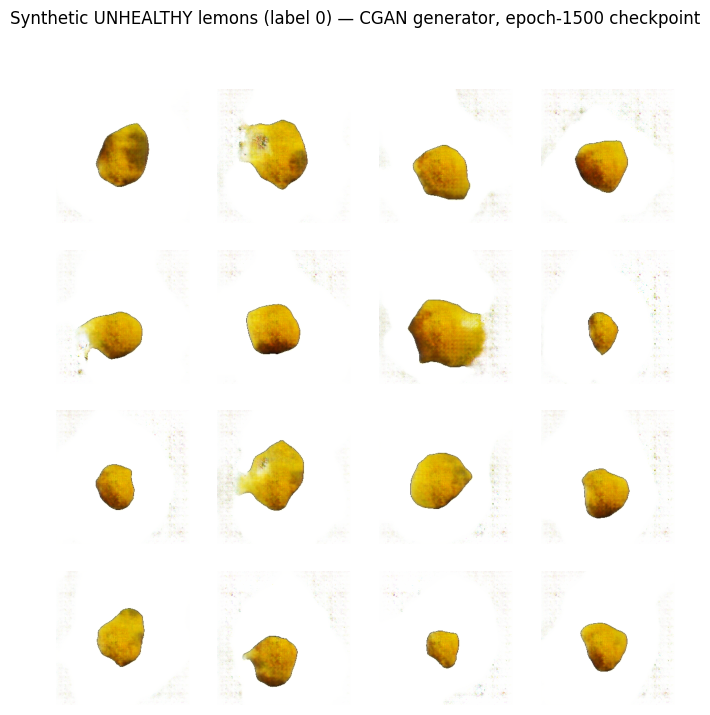

In [ ]:
X_unhealthy = loaded.predict([latent_unhealthy, labels_unhealthy], verbose=0)
print('raw output', X_unhealthy.shape, 'range [%.4f, %.4f]' % (X_unhealthy.min(), X_unhealthy.max()))
X_unhealthy = (X_unhealthy + 1) / 2.0
print('rescaled  ', X_unhealthy.shape, 'range [%.4f, %.4f]' % (X_unhealthy.min(), X_unhealthy.max()))

save_plot(X_unhealthy, 4, 'Synthetic UNHEALTHY lemons (label 0) — CGAN generator, epoch-1500 checkpoint')

### Generate 16 synthetic **healthy** lemons (ラベル1の合成画像を生成)
Same inference path with `class_to_gen=1`, i.e. all labels equal 1. Per the paper's Grad-CAM analysis
(Section 4.2), the classifier attends to the overall fruit shape for healthy synthesis, so these should look
like whole, defect-free lemons on a plain background.
**日本語:** 健康（ラベル1）の合成レモンを16枚生成して表示します。

raw output (16, 256, 256, 3) range [-0.9999, 1.0000]
rescaled   (16, 256, 256, 3) range [0.0000, 1.0000]


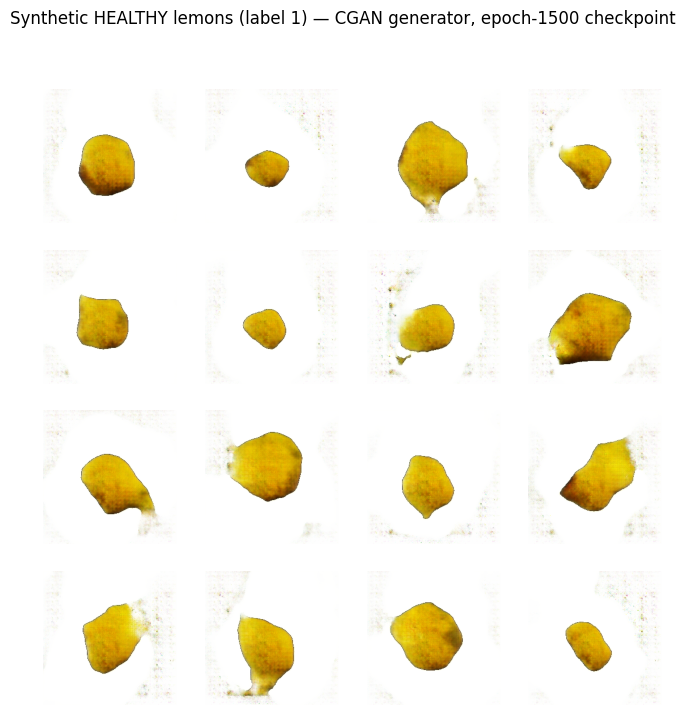

In [ ]:
X_healthy = loaded.predict([latent_healthy, labels_healthy], verbose=0)
print('raw output', X_healthy.shape, 'range [%.4f, %.4f]' % (X_healthy.min(), X_healthy.max()))
X_healthy = (X_healthy + 1) / 2.0
print('rescaled  ', X_healthy.shape, 'range [%.4f, %.4f]' % (X_healthy.min(), X_healthy.max()))

save_plot(X_healthy, 4, 'Synthetic HEALTHY lemons (label 1) — CGAN generator, epoch-1500 checkpoint')

### Side-by-side comparison grid (比較図 — このノートブックで作成した追加図)
A labeled 2-row comparison (top: synthetic unhealthy, bottom: synthetic healthy) created **for this notebook**
from the images generated above — it is not an author figure, but it mirrors the layout of the repository's
`comparison.png` (real vs synthetic). This figure is also the published preview for this reproduction.
**日本語:** 上段=不健康、下段=健康の比較図です（このノートブックで作成した追加図であり、著者の図では
ありません）。

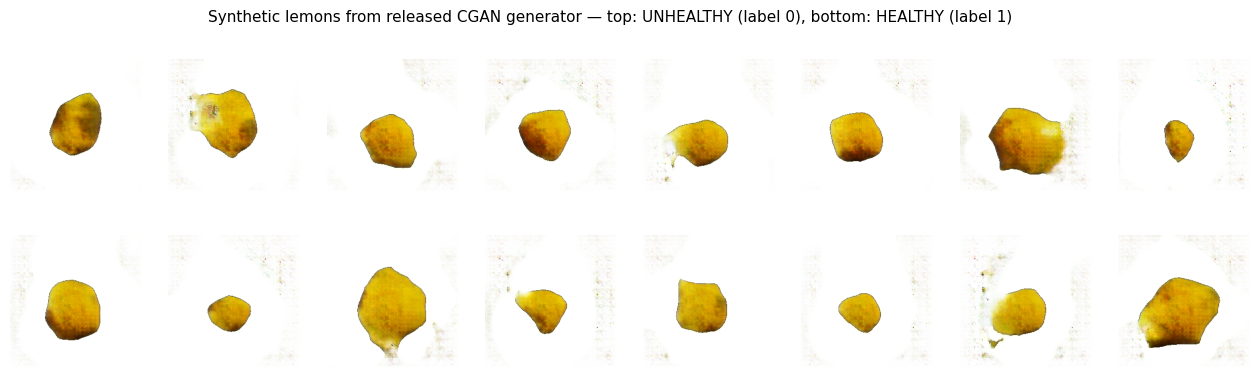

In [ ]:
fig = plt.figure(figsize=(16, 4.2))
for i in range(8):
    ax = fig.add_subplot(2, 8, 1 + i); ax.axis('off'); ax.imshow(X_unhealthy[i])
    ax = fig.add_subplot(2, 8, 9 + i); ax.axis('off'); ax.imshow(X_healthy[i])
fig.suptitle('Synthetic lemons from released CGAN generator — top: UNHEALTHY (label 0), bottom: HEALTHY (label 1)', fontsize=11)
plt.show()

### Export the generated samples (サンプルの書き出し)
Preserves the authors' file-export behavior (`save_plot` → `pyplot.imsave`) on this small subset: each image is
written as a JPEG under `/content/synthetic_lemons/{unhealthy,healthy}/`, plus a `samples.csv` index recording
sample id, class label, source checkpoint, seed, and repository commit — a small inspectable table and the
run's provenance record. Files stay on the Colab VM.
**日本語:** 著者コードと同様にJPEGで保存し、`samples.csv` にサンプル索引（クラス・シード・コミット等）を
記録します。

In [ ]:
import csv, os

OUT_DIR = '/content/synthetic_lemons'
rows = []
for cls_name, X in [('unhealthy', X_unhealthy), ('healthy', X_healthy)]:
    d = os.path.join(OUT_DIR, cls_name)
    os.makedirs(d, exist_ok=True)
    for i in range(X.shape[0]):
        fn = f'{cls_name}_{i:02d}.jpg'
        plt.imsave(os.path.join(d, fn), X[i])
        rows.append({'file': f'{cls_name}/{fn}', 'label': 0 if cls_name == 'unhealthy' else 1,
                     'class': cls_name})

with open(os.path.join(OUT_DIR, 'samples.csv'), 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['file', 'label', 'class'])
    w.writeheader(); w.writerows(rows)

print('saved %d images to %s' % (len(rows), OUT_DIR))
print('csv: %s/samples.csv' % OUT_DIR)
print(open(os.path.join(OUT_DIR, 'samples.csv')).read())

saved 32 images to /content/synthetic_lemons
csv: /content/synthetic_lemons/samples.csv
file,label,class
unhealthy/unhealthy_00.jpg,0,unhealthy
unhealthy/unhealthy_01.jpg,0,unhealthy
unhealthy/unhealthy_02.jpg,0,unhealthy
unhealthy/unhealthy_03.jpg,0,unhealthy
unhealthy/unhealthy_04.jpg,0,unhealthy
unhealthy/unhealthy_05.jpg,0,unhealthy
unhealthy/unhealthy_06.jpg,0,unhealthy
unhealthy/unhealthy_07.jpg,0,unhealthy
unhealthy/unhealthy_08.jpg,0,unhealthy
unhealthy/unhealthy_09.jpg,0,unhealthy
unhealthy/unhealthy_10.jpg,0,unhealthy
unhealthy/unhealthy_11.jpg,0,unhealthy
unhealthy/unhealthy_12.jpg,0,unhealthy
unhealthy/unhealthy_13.jpg,0,unhealthy
unhealthy/unhealthy_14.jpg,0,unhealthy
unhealthy/unhealthy_15.jpg,0,unhealthy
healthy/healthy_00.jpg,1,healthy
healthy/healthy_01.jpg,1,healthy
healthy/healthy_02.jpg,1,healthy
healthy/healthy_03.jpg,1,healthy
healthy/healthy_04.jpg,1,healthy
healthy/healthy_05.jpg,1,healthy
healthy/healthy_06.jpg,1,healthy
healthy/healthy_07.jpg,1,healthy
healthy

## Interpretation, differences from the paper, and validation record (解釈と検証記録)

**What this run demonstrates.** The authors' released generator produces class-conditional 256×256 RGB lemon
syntheses with the exact latent/label scheme of `generate_lemons.py`: a 100-dim Gaussian latent vector plus an
integer label (0 = unhealthy, 1 = healthy), tanh output rescaled by (X+1)/2. This is the paper's data-augmentation
generation step (Sections 3.2, 4.2), which the paper says underpinned the 88.75% accuracy result of Table 2.

**Differences from the paper (documented deviations):**
- Checkpoint is the highest available in the repository, **epoch 1500**, not the 2000-epoch final generator
  described in Section 3.2 (the 2000-epoch file is not checked in).
- 16 samples per class (seeded, `numpy.random.seed(0)`) instead of the author script's 1000 unseeded files per run.
- Loader uses `tf-keras` (Keras 2 lineage) because the file is a TF-2.4-era legacy H5; the numerical graph is
  unchanged, only the deserialization path.
- No classifier, Grad-CAM, pruning, or augmented-accuracy comparison is reproduced — those depend on the
  unreleased VGG16 training code and the 2690-image dataset; the single-example run does **not** verify any
  published accuracy figure.

**Provenance:** author code and checkpoint from `jordan-bird/synthetic-fruit-image-generator` at commit
`1c3d420d7d6e511d7e63b2a125eac52d277010bc`; blob SHA-1 verified on download. Paper: Bird et al., arXiv:2104.05647v1; *Scientia Horticulturae*
293:110684 (2022). CGAN tutorial lineage: Brownlee (MachineLearningMastery) per the authors' README.
**日本語:** 本実行は公開済み生成器によるデータ拡張用画像生成の最小再現であり、論文の精度結果（Table 2 等）
の検証ではありません。チェックポイントは1500エポック版、サンプル数は16枚/クラス、シード固定という
資料上の差異があります。